<a href="https://colab.research.google.com/github/Dubey911/thiranex/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (2240, 29)
Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMont

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Set seed for reproducibility
np.random.seed(42)

# Load dataset
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# 1. Data Cleaning
df['Income'] = df['Income'].fillna(df['Income'].median())

# Parse Dt_Customer
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
max_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (max_date - df['Dt_Customer']).dt.days

# Feature Engineering
df['Age'] = 2015 - df['Year_Birth']
df['TotalSpent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['TotalPurchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
df['Children'] = df['Kidhome'] + df['Teenhome']

# Filter extreme outliers
df = df[(df['Age'] < 90) & (df['Income'] < 200000)].copy()

# Features for Clustering
clustering_features = ['Income', 'TotalSpent', 'TotalPurchases', 'Recency', 'Age', 'Children', 'Customer_Tenure_Days']
X = df[clustering_features]

# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Silhouette Analysis to find optimal K
sil_scores = []
k_range = range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# K=4 gives excellent balance and business interpretability
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
df['PCA1'] = pca_coords[:, 0]
df['PCA2'] = pca_coords[:, 1]

# Cluster Profiles Summary
cluster_summary = df.groupby('Cluster')[['Income', 'TotalSpent', 'TotalPurchases', 'Recency', 'Age', 'Children']].mean().round(1)
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_summary['Customer_Count'] = cluster_counts
cluster_summary['Percentage'] = (cluster_counts / len(df) * 100).round(1)

print(cluster_summary)

          Income  TotalSpent  TotalPurchases  Recency   Age  Children  \
Cluster                                                                 
0        60234.3       808.8            18.0     47.6  51.4       1.0   
1        77870.2      1428.4            19.6     50.7  45.5       0.1   
2        42918.3       145.6             7.1     50.7  51.1       1.9   
3        30384.5       109.7             6.1     48.0  37.9       0.8   

         Customer_Count  Percentage  
Cluster                              
0                   585        26.2  
1                   518        23.2  
2                   492        22.0  
3                   641        28.7  


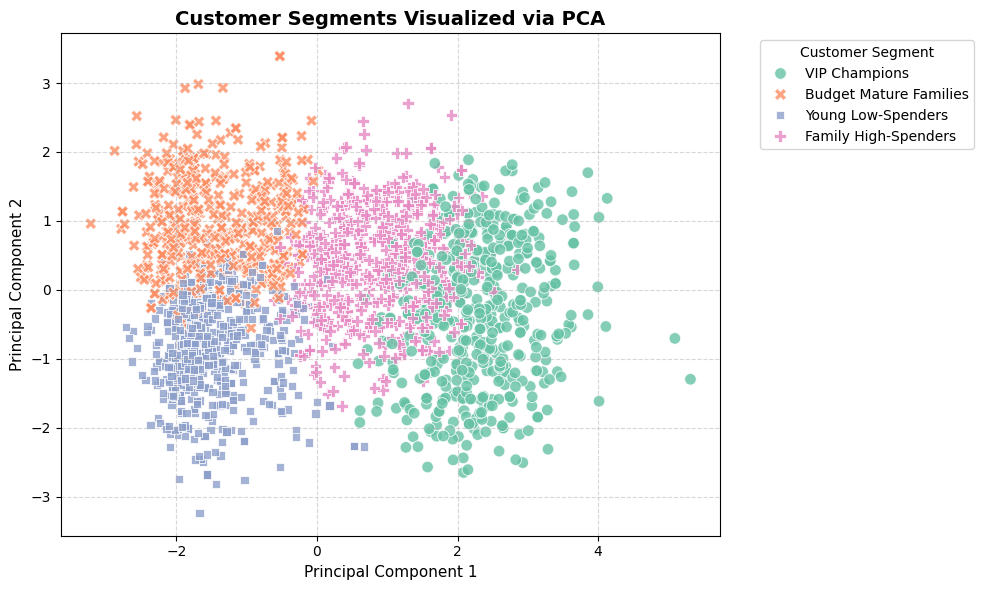

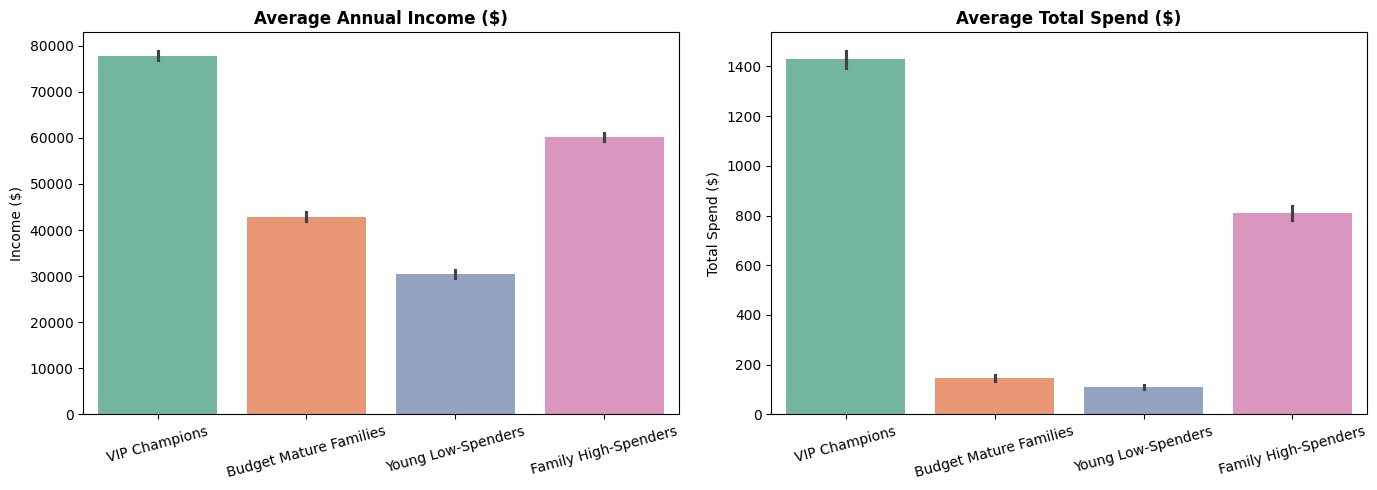

Plots created successfully!


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# MAP DESCRIPTIVE CLUSTER LABELS
# ============================================================

cluster_labels = {
    1: 'VIP Champions',
    0: 'Family High-Spenders',
    2: 'Budget Mature Families',
    3: 'Young Low-Spenders'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_labels)


# ============================================================
# PLOT 1: 2D PCA CLUSTERS SCATTER PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster_Name',
    palette='Set2',
    style='Cluster_Name',
    s=70,
    alpha=0.8
)

plt.title(
    'Customer Segments Visualized via PCA',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Principal Component 1',
    fontsize=11
)

plt.ylabel(
    'Principal Component 2',
    fontsize=11
)

plt.legend(
    title='Customer Segment',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    'customer_clusters_pca.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close()


# ============================================================
# PLOT 2: KEY METRICS COMPARISON
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# Average Income
# ------------------------------------------------------------

sns.barplot(
    data=df,
    x='Cluster_Name',
    y='Income',
    hue='Cluster_Name',
    palette='Set2',
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    'Average Annual Income ($)',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_ylabel(
    'Income ($)'
)

axes[0].set_xlabel('')

axes[0].tick_params(
    axis='x',
    rotation=15
)


# ------------------------------------------------------------
# Average Total Spend
# ------------------------------------------------------------

sns.barplot(
    data=df,
    x='Cluster_Name',
    y='TotalSpent',
    hue='Cluster_Name',
    palette='Set2',
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    'Average Total Spend ($)',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_ylabel(
    'Total Spend ($)'
)

axes[1].set_xlabel('')

axes[1].tick_params(
    axis='x',
    rotation=15
)


# ============================================================
# SAVE METRICS COMPARISON
# ============================================================

plt.tight_layout()

plt.savefig(
    'cluster_metrics_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close()


print("Plots created successfully!")

In [6]:
# Get detailed cluster statistics
summary_detailed = df.groupby('Cluster_Name').agg(
    Count=('ID', 'count'),
    Avg_Income=('Income', 'mean'),
    Avg_Spent=('TotalSpent', 'mean'),
    Avg_Purchases=('TotalPurchases', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Age=('Age', 'mean'),
    Avg_Children=('Children', 'mean')
).reset_index()

# Calculate percentage
summary_detailed['Pct_Customers'] = (summary_detailed['Count'] / len(df) * 100).round(1)
summary_detailed['Avg_Income'] = summary_detailed['Avg_Income'].round(0)
summary_detailed['Avg_Spent'] = summary_detailed['Avg_Spent'].round(0)
summary_detailed['Avg_Purchases'] = summary_detailed['Avg_Purchases'].round(1)
summary_detailed['Avg_Age'] = summary_detailed['Avg_Age'].round(1)
summary_detailed['Avg_Children'] = summary_detailed['Avg_Children'].round(1)

print(summary_detailed.to_string())

             Cluster_Name  Count  Avg_Income  Avg_Spent  Avg_Purchases  Avg_Recency  Avg_Age  Avg_Children  Pct_Customers
0  Budget Mature Families    492     42918.0      146.0            7.1    50.695122     51.1           1.9           22.0
1    Family High-Spenders    585     60234.0      809.0           18.0    47.557265     51.4           1.0           26.2
2           VIP Champions    518     77870.0     1428.0           19.6    50.698842     45.5           0.1           23.2
3      Young Low-Spenders    641     30384.0      110.0            6.1    48.048362     37.9           0.8           28.7
